In [ ]:
# Packages to install
#%pip install tensorflow
#%pip install pandas numpy matplotlib seaborn
#%pip install scikit-learn
#%pip install keras_tuner
#%pip install imblearn
#%pip install scikeras
#%pip install tqdm

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, precision_recall_fscore_support
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
import tensorflow.keras.backend as K
import keras_tuner as kt
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from scikeras.wrappers import KerasRegressor 
from tensorflow.keras.losses import MeanSquaredError
import os
from itertools import product


In [2]:

df = pd.read_csv("dataset_mood_smartphone.csv")

# Convert time to datetime format
df['time'] = pd.to_datetime(df['time'], dayfirst=True)

# Extract Date 
df['date'] = df['time'].dt.date
df = df.drop(columns=['time']
             )
# Convert value to numeric
df['value'] = pd.to_numeric(df['value'], errors='coerce')

# Define variables to be averaged - the others will be summed
mood_vars = ['mood', 'circumplex.valence', 'circumplex.arousal','activity']

# Separate mood (and activity) vs other data
df_mood = df[df['variable'].isin(mood_vars)]
df_other = df[~df['variable'].isin(mood_vars)]

#Pivot table, one row per (ID, Date), columns are Variables
# average for mood variables and activity
pivot_mood = df_mood.pivot_table(index=['id', 'date'],
                                 columns='variable',
                                 values='value',
                                 aggfunc='mean')

# Pivot: sum for all other variables
pivot_other = df_other.pivot_table(index=['id', 'date'],
                                   columns='variable',
                                   values='value',
                                   aggfunc='sum')

# Merge both pivot tables on 'id' and 'date'
data = pd.merge(pivot_mood, pivot_other, on=['id', 'date'], how='outer')

# Sort values by ID and Date
data = data.sort_values(by=['id', 'date'])

if 'id' not in data.columns or 'date' not in data.columns:
    data = data.reset_index()

print(data.head())


C:\Users\vasso\AppData\Local\Temp\ipykernel_22132\3020394736.py:4: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['time'] = pd.to_datetime(df['time'], dayfirst=True)


variable       id        date  activity  circumplex.arousal  \
0         AS14.01  2014-02-17       NaN                 NaN   
1         AS14.01  2014-02-18       NaN                 NaN   
2         AS14.01  2014-02-19       NaN                 NaN   
3         AS14.01  2014-02-20       NaN                 NaN   
4         AS14.01  2014-02-21       NaN                 NaN   

variable  circumplex.valence  mood  appCat.builtin  appCat.communication  \
0                        NaN   NaN             NaN                   NaN   
1                        NaN   NaN             NaN                   NaN   
2                        NaN   NaN             NaN                   NaN   
3                        NaN   NaN             NaN                   NaN   
4                        NaN   NaN             NaN                   NaN   

variable  appCat.entertainment  appCat.finance  ...  appCat.office  \
0                          NaN             NaN  ...            NaN   
1                       

Number of unique users: 27
id
AS14.01    21999
AS14.02    14581
AS14.03    14425
AS14.05    15745
AS14.06    18092
AS14.07    16045
AS14.08     7902
AS14.09    10886
AS14.12    17311
AS14.13    19592
AS14.14     9286
AS14.15     2848
AS14.16     3982
AS14.17    15826
AS14.19    11397
AS14.20     3620
AS14.23    21852
AS14.24    14430
AS14.25    12589
AS14.26    16403
AS14.27    14575
AS14.28    19276
AS14.29    17499
AS14.30    17279
AS14.31    11889
AS14.32    11193
AS14.33    16390
dtype: int64
Average records per user: 13959.703703703704
Min records per user: 2848
Max records per user: 21999


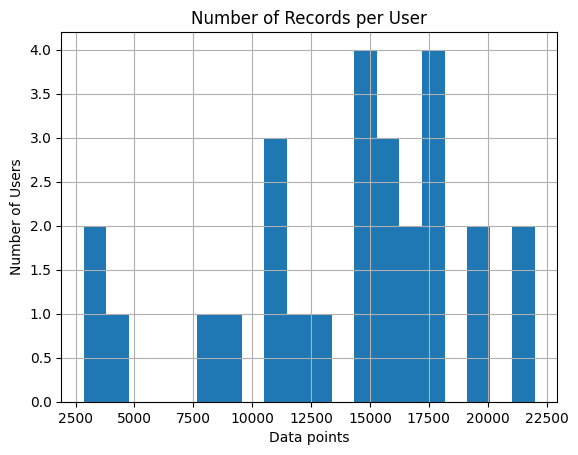

In [3]:
# Total number of users
num_users = data['id'].nunique()
print("Number of unique users:", num_users)

# Number of records per user (days per user)
records_per_user = df.groupby('id').size()
print(records_per_user)

print("Average records per user:", records_per_user.mean())
print("Min records per user:", records_per_user.min())
print("Max records per user:", records_per_user.max())

records_per_user.hist(bins=20)
plt.title("Number of Records per User")
plt.xlabel("Data points")
plt.ylabel("Number of Users")
plt.show()



Number of records (rows): 1973
Number of attributes (columns): 21
                      Missing Count  Missing %
variable                                      
appCat.weather                 1860  94.272681
appCat.game                    1780  90.217942
appCat.finance                 1766  89.508363
appCat.unknown                 1709  86.619361
appCat.office                  1697  86.011151
appCat.travel                  1544  78.256462
appCat.utilities               1540  78.053725
sms                            1239  62.797770
appCat.entertainment           1123  56.918398
appCat.social                   985  49.923974
appCat.other                    853  43.233654
appCat.communication            790  40.040547
activity                        785  39.787126
appCat.builtin                  778  39.432337
screen                          766  38.824126
circumplex.valence              707  35.833756
circumplex.arousal              705  35.732387
mood                            705  35.7

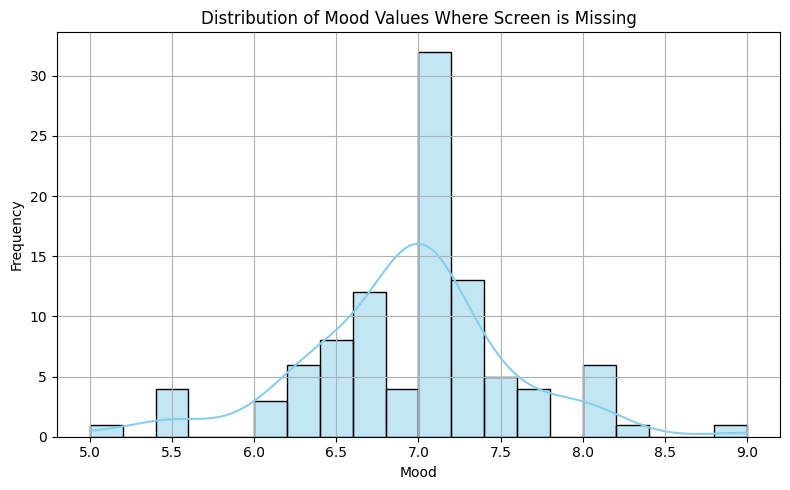

In [ ]:
# Shape
print("Number of records (rows):", data.shape[0])
print("Number of attributes (columns):", data.shape[1])

# Missing values
missing = data.isnull().sum()
missing_percent = 100 * data.isnull().mean()
missing_table = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
missing_table = missing_table[missing_table['Missing Count'] > 0].sort_values(by='Missing %', ascending=False)

print(missing_table)

# Check how many missing values in screen and activity
missing_screen = data[data['screen'].isna()]
missing_activity = data[data['activity'].isna()]

print(f"Missing screen rows: {len(missing_screen)}")
print(f"Missing activity rows: {len(missing_activity)}")

# Do they overlap?
both_missing = data[data['screen'].isna() & data['activity'].isna()]
print(f"Rows where both screen and activity are missing: {len(both_missing)}")

# Count non-NaN values for each column in these rows
screen_missing_non_nan_summary = missing_screen.notna().sum().sort_values(ascending=False)
print("Non-NaN counts in rows where screen is missing:")
print(screen_missing_non_nan_summary)

# Count non-NaN values for each column in these rows
activity_missing_non_nan_summary = missing_activity.notna().sum().sort_values(ascending=False)
print("\nNon-NaN counts in rows where activity is missing:")
print(activity_missing_non_nan_summary)

# Mood values where screen is missing
#print("\nMood values in rows where screen is missing:")
#print(missing_screen[['id', 'date', 'mood']].dropna(subset=['mood']))

# Drop rows with missing mood in missing_screen
mood_missing_screen = missing_screen['mood'].dropna()

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(mood_missing_screen, bins=20, kde=True, color='skyblue')
plt.title("Distribution of Mood Values Where Screen is Missing")
plt.xlabel("Mood")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

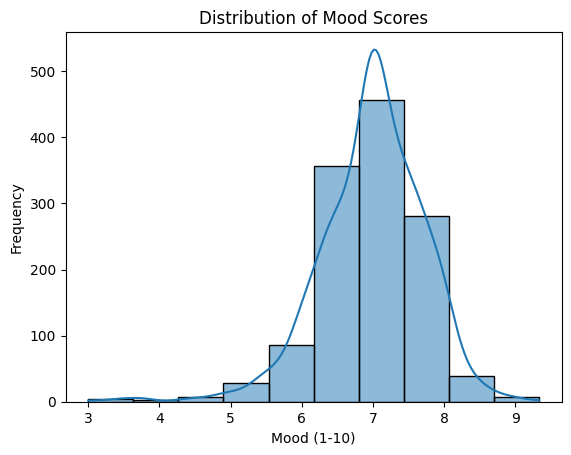

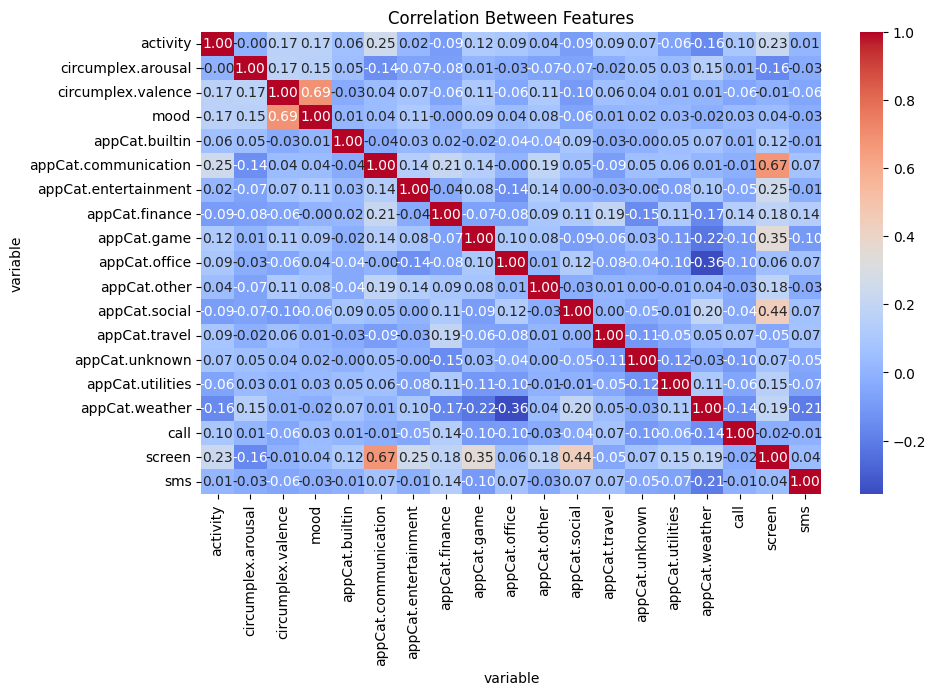

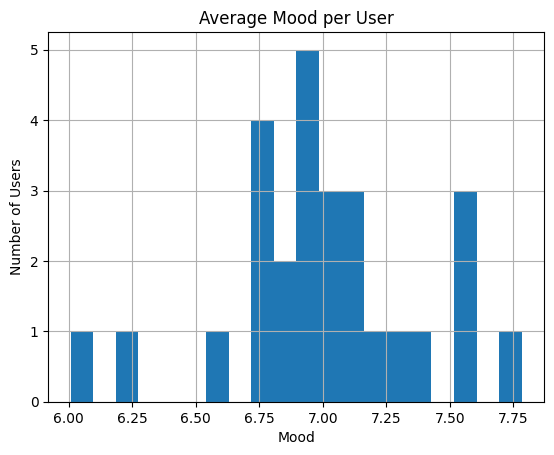

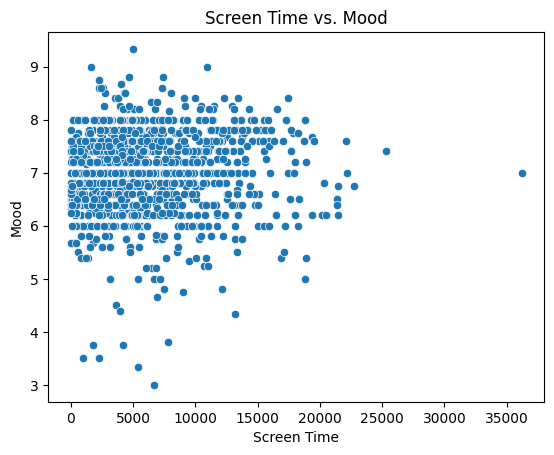

In [5]:
# Distribution of mood scores
sns.histplot(data['mood'].dropna(), bins=10, kde=True)
plt.title("Distribution of Mood Scores")
plt.xlabel("Mood (1-10)")
plt.ylabel("Frequency")
plt.show()

# Select only numeric columns
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Features")
plt.show()

# Average mood per user
mood_per_user = data.groupby("id")["mood"].mean()
mood_per_user.hist(bins=20)
plt.title("Average Mood per User")
plt.xlabel("Mood")
plt.ylabel("Number of Users")
plt.show()

# Relationship between screen time and mood
sns.scatterplot(x='screen', y='mood', data=data)
plt.title("Screen Time vs. Mood")
plt.xlabel("Screen Time")
plt.ylabel("Mood")
plt.show()

In [6]:
# Impute Variables Based on Strategy
# Define lists of variables
mood_vars = ['mood', 'circumplex.valence', 'circumplex.arousal']
fill_zero_vars = [col for col in data.columns if col.startswith('appCat.')] + ['sms', 'call', 'screen', 'activity']

# Apply imputation per user (grouped)
def impute_group(group):
   # group = group.drop(columns='id')  # Drop grouping column to avoid future warning
    group = group.sort_values('date')

    # Forward fill for mood-related
    group[mood_vars] = group[mood_vars].ffill()


    # Fill missing values for app categories, sms, and call with zeros
    group[fill_zero_vars] = group[fill_zero_vars].fillna(0)

    return group


# Group by user and apply imputation
imputed_data = (
    data.groupby('id', group_keys=False)
        .apply(lambda group: impute_group(group))
        .reset_index(drop=True)
)

# Fill app category usage (missing → 0)
imputed_data[fill_zero_vars] = imputed_data[fill_zero_vars].fillna(0)

# Drop rows where mood still missing after imputation
imputed_data = imputed_data.dropna(subset=['mood'])

missing_summary = imputed_data.isna().sum()
print("Missing Values After Imputation:")
print(missing_summary[missing_summary > 0])

print(imputed_data.columns)

Missing Values After Imputation:
Series([], dtype: int64)
Index(['id', 'date', 'activity', 'circumplex.arousal', 'circumplex.valence',
       'mood', 'appCat.builtin', 'appCat.communication',
       'appCat.entertainment', 'appCat.finance', 'appCat.game',
       'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel',
       'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call',
       'screen', 'sms'],
      dtype='object', name='variable')


C:\Users\vasso\AppData\Local\Temp\ipykernel_22132\770316764.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: impute_group(group))


In [7]:
# Detect prolonged missing periods

# Sort by user and date
imputed_data = imputed_data.sort_values(by=['id', 'date'])

imputed_data['date'] = pd.to_datetime(imputed_data['date'], errors='coerce')

# Calculate gap in days between consecutive rows per user
imputed_data['date_diff'] = imputed_data.groupby('id')['date'].diff().dt.days

# Flag gaps longer than 1 day
gap_threshold = 1
gaps = imputed_data[imputed_data['date_diff'] > gap_threshold]

print(gaps[['id', 'date', 'date_diff']])

# Count number of gaps > threshold per user
#gap_summary = imputed_data[imputed_data['date_diff'] > gap_threshold].groupby('id')['date_diff'].agg(['count', 'mean', 'max'])
#print(gap_summary)


variable       id       date  date_diff
11        AS14.01 2014-03-03        2.0
12        AS14.01 2014-03-05        2.0
15        AS14.01 2014-03-10        3.0
571       AS14.12 2014-03-18        2.0
575       AS14.12 2014-03-25        4.0
576       AS14.12 2014-03-27        2.0
1776      AS14.31 2014-05-07        2.0
1785      AS14.31 2014-05-17        2.0


In [8]:
# Initialize Parameters
window_size = 3
gap_threshold = 1
rows = []

# Period column
current_period = 1  # Start the period from 1 for each patient

# Sort by patient and date and prepare data
imputed_data = imputed_data.sort_values(by=['id', 'date'])
imputed_data['date'] = pd.to_datetime(imputed_data['date'], errors='coerce')

# Compute date differences and flag prolonged gaps
imputed_data['date_diff'] = imputed_data.groupby('id')['date'].diff().dt.days
imputed_data['prolonged_gap'] = imputed_data['date_diff'] > gap_threshold

# Optional: flag rows immediately following a gap
imputed_data['post_gap'] = False
def mark_post_gap(group):
    indices = group.index[group['prolonged_gap']]
    for idx in indices:
        # mark next (window_size - 1) rows after the gap to avoid invalid windows
        post_gap_indices = group.index[(group.index > idx) & (group.index <= idx + (window_size - 1))]
        group.loc[post_gap_indices, 'post_gap'] = True
    return group

imputed_data = imputed_data.groupby('id').apply(mark_post_gap).reset_index(drop=True)

# App category columns (except for other, unknown, builtin and utilities)
appcat_cols = [col for col in imputed_data.columns if col.startswith("appCat.") and col not in ["appCat.other", "appCat.unknown", "appCat.builtin", "appCat.utilities"]]

# Create weights for the weighted average (e.g., more recent days count more)
weights = np.arange(1, window_size + 1)

for patient_id, group in imputed_data.groupby('id'):
    group = group.sort_values('date').reset_index(drop=True)
    
    for i in range(window_size, len(group)):
        window = group.iloc[i - window_size:i]
        target_row = group.iloc[i]

        # Skip if any row in window or target row is flagged due to a gap
        if window['post_gap'].any() or target_row['post_gap']:
            continue

        row_data = {
            'id': patient_id,
            'date': target_row['date'],  # This is the date of the target (prediction)
            'mood': target_row['mood'],  # The target variable you're predicting
            'period': f"t={current_period}-{current_period + window_size - 1}"  # Period column (e.g., t=1-5, t=2-6)
        }
          
        # Weighted average of activity
        row_data['activity_avg'] = np.average(window['activity'], weights=weights)

        # Weighted average for each app category
        for col in appcat_cols:
            row_data[f'{col}_avg'] = np.average(window[col], weights=weights)
            
            # Boolean: used app from this category at least once in 5 days
            row_data[f'{col}_used'] = int((window[col] > 0).any())

        # Merge 'other' and 'unknown' app usage into a new category
        if "appCat.other" in window.columns and "appCat.unknown" in window.columns:
           merged_usage = window['appCat.other'] + window['appCat.unknown']
           row_data['appCat.merged_other_unknown_avg'] = np.average(merged_usage, weights=weights)
           row_data['appCat.merged_other_unknown_used'] = int((merged_usage > 0).any())

        # Merge 'builtin' and 'utilities' app usage into a new category
        if "appCat.builtin" in window.columns and "appCat.utilities" in window.columns:
           merged_usage = window['appCat.builtin'] + window['appCat.utilities']
           row_data['appCat.merged_builtin_utilities_avg'] = np.average(merged_usage, weights=weights)
           row_data['appCat.merged_builtin_utilities_used'] = int((merged_usage > 0).any())

        # Weighted average screen time
        row_data['screen_avg'] = np.average(window['screen'], weights=weights)

        # Weighted average of the sum of sms + call
        sms_call = window['sms'] + window['call']
        row_data['sms_call_sum_weighted_avg'] = np.average(sms_call, weights=weights)

        # Weighted average of arousal, valence, and mood
        row_data['arousal_avg'] = np.average(window['circumplex.arousal'], weights=weights)
        row_data['valence_avg'] = np.average(window['circumplex.valence'], weights=weights)
        row_data['mood_avg'] = np.average(window['mood'], weights=weights)

        rows.append(row_data)
        # Update the period for the next row
        current_period += 1

# Final instance-based dataset
final_dataset = pd.DataFrame(rows)

# Columns to drop
drop_avg_for_boolean_apps = [
    'appCat.weather_avg', 'appCat.travel_avg', 'appCat.finance_avg'
]

drop_boolean_for_avg_apps = [
    'appCat.entertainment_used', 'appCat.social_used', 'appCat.communication_used',
    'appCat.game_used', 'appCat.office_used', 'appCat.merged_builtin_utilities_used',
    'appCat.merged_other_unknown_used'
]

# Drop the unnecessary columns
final_dataset = final_dataset.drop(columns=drop_avg_for_boolean_apps + drop_boolean_for_avg_apps, errors='ignore')


print(final_dataset.columns)
print(final_dataset.head())

C:\Users\vasso\AppData\Local\Temp\ipykernel_22132\1790718716.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  imputed_data = imputed_data.groupby('id').apply(mark_post_gap).reset_index(drop=True)


Index(['id', 'date', 'mood', 'period', 'activity_avg',
       'appCat.communication_avg', 'appCat.entertainment_avg',
       'appCat.finance_used', 'appCat.game_avg', 'appCat.office_avg',
       'appCat.social_avg', 'appCat.travel_used', 'appCat.weather_used',
       'appCat.merged_other_unknown_avg',
       'appCat.merged_builtin_utilities_avg', 'screen_avg',
       'sms_call_sum_weighted_avg', 'arousal_avg', 'valence_avg', 'mood_avg'],
      dtype='object')
        id       date      mood period  activity_avg  \
0  AS14.01 2014-03-01  6.333333  t=1-3           0.0   
1  AS14.01 2014-03-03  6.333333  t=2-4           0.0   
2  AS14.01 2014-03-16  6.333333  t=3-5           0.0   
3  AS14.01 2014-03-17  6.333333  t=4-6           0.0   
4  AS14.01 2014-03-18  6.333333  t=5-7           0.0   

   appCat.communication_avg  appCat.entertainment_avg  appCat.finance_used  \
0                       0.0                       0.0                    0   
1                       0.0                

In [9]:

# Save final dataset as CSV
final_dataset.to_csv('final_dataset.csv', index=False)


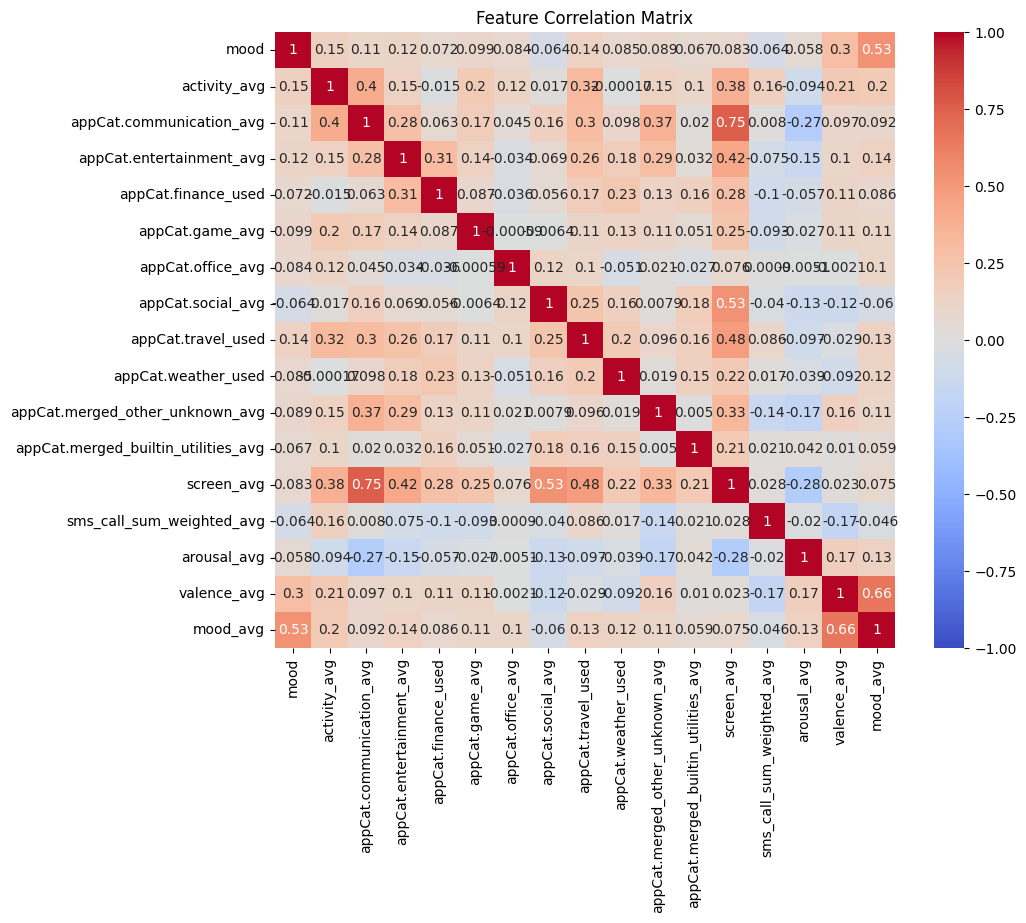

In [10]:
## Check again the correlations with mood

# Convert boolean columns to integers
boolean_cols = [
    'appCat.finance_used', 'appCat.travel_used', 'appCat.weather_used'
]

# Apply boolean conversion to integer 
final_dataset[boolean_cols] = final_dataset[boolean_cols].astype(int)

# Keep only numeric columns 
numeric_cols = final_dataset.select_dtypes(include=['number']).columns
numeric_data = final_dataset[numeric_cols]

# Calculate the correlation matrix
correlation_matrix = numeric_data.corr()

# Display correlation with the target 'mood'
correlation_with_mood = correlation_matrix['mood'].sort_values(ascending=False)

# Plot correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

In [11]:
# Convert mood into classes for Classification 
# Convert mood into 3 classes using quantile split
final_dataset['mood_class'] = pd.qcut(final_dataset['mood'], q=3, labels=[0, 1, 2]).astype(int)

# show bin edges and class distribution
mood_qcut, bin_edges = pd.qcut(final_dataset['mood'], q=3, retbins=True, labels=False)
print("Mood Class Distribution:")
print(pd.Series(mood_qcut).value_counts().sort_index())

print("\nQuantile Bin Edges:")
print(f"Class 0 (Low mood):    mood in [{bin_edges[0]:.2f}, {bin_edges[1]:.2f})")
print(f"Class 1 (Medium mood): mood in [{bin_edges[1]:.2f}, {bin_edges[2]:.2f})")
print(f"Class 2 (High mood):   mood in [{bin_edges[2]:.2f}, {bin_edges[3]:.2f})")

Mood Class Distribution:
mood
0    464
1    363
2    399
Name: count, dtype: int64

Quantile Bin Edges:
Class 0 (Low mood):    mood in [3.00, 6.80)
Class 1 (Medium mood): mood in [6.80, 7.25)
Class 2 (High mood):   mood in [7.25, 9.33)


In [12]:
## Classification with Random Forest

# Define features X and target y
#    Drop columns you don’t want the model to see
drop_cols = ['id', 'date', 'period']   
X = final_dataset.drop(columns=drop_cols + ['mood', 'mood_class'])
y = final_dataset['mood_class']
groups = final_dataset['id']

# Hold‑out 20% of users for final evaluation
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

print("Class counts:")
print(y_train.value_counts())

# Define pipeline: SMOTE + RandomForest
pipeline = Pipeline([
    #('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Define classifier
#clf = RandomForestClassifier(random_state=42, class_weight='balanced')

# Define hyperparameter grid
param_grid = {
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
    'clf__n_estimators': [100, 200]
}

# GroupKFold (ensures no data leakage across users)
gkf = GroupKFold(n_splits=5)

# Grid search with GroupKFold
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=gkf.split(X_train, y_train, groups=groups_train),
    scoring='f1_weighted', 
    n_jobs=-1,
    verbose=1
)

# Fit model
grid_search.fit(X_train, y_train)

# Get the best model from grid search
best_model = grid_search.best_estimator_

# Print the best hyperparameters found by GridSearchCV
print("Best Parameters:", grid_search.best_params_)

# Make predictions on the test set
y_pred = best_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy: ", accuracy)

# Get the detailed classification report
report = classification_report(y_test, y_pred, output_dict=True)

# Extract and print precision, recall, F1 for each class
for cls in ['0', '1', '2']:
    print(f"Class {cls} - Precision: {report[cls]['precision']:.2f}, Recall: {report[cls]['recall']:.2f}, F1-Score: {report[cls]['f1-score']:.2f}")

# Print the weighted average F1-score
print("Weighted Average F1-Score:", report['weighted avg']['f1-score'])

Class counts:
mood_class
0    362
2    313
1    265
Name: count, dtype: int64
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'clf__max_depth': 10, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}
Test Accuracy:  0.534965034965035
Class 0 - Precision: 0.60, Recall: 0.70, F1-Score: 0.65
Class 1 - Precision: 0.48, Recall: 0.41, F1-Score: 0.44
Class 2 - Precision: 0.49, Recall: 0.49, F1-Score: 0.49
Weighted Average F1-Score: 0.5293597720228084


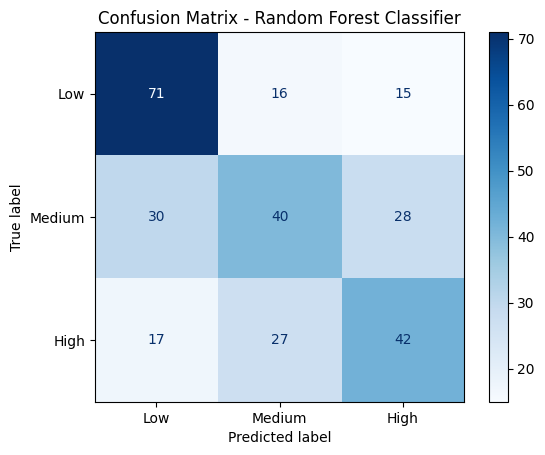

In [13]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix with correct labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "Medium", "High"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest Classifier")
plt.show()

In [14]:
### FEATURES USED FROM COMPLEX MODELS

# Merge 'utilities' and 'builtin'
imputed_data['appCat.builtin_utilities'] = imputed_data['appCat.builtin'] + imputed_data['appCat.utilities']
imputed_data.drop(['appCat.builtin', 'appCat.utilities'], axis=1, inplace=True)

# Merge 'other' and 'unknown'
imputed_data['appCat.other_unknown'] = imputed_data['appCat.other'] + imputed_data['appCat.unknown']
imputed_data.drop(['appCat.other', 'appCat.unknown'], axis=1, inplace=True)

# Merge 'sms' and 'call'
imputed_data['call_sms'] = imputed_data['sms'] + imputed_data['call']
imputed_data.drop(['sms', 'call'], axis=1, inplace=True)

imputed_data['appCat.weather'] = (imputed_data['appCat.weather'] > 0).astype(int)
imputed_data['appCat.finance'] = (imputed_data['appCat.finance'] > 0).astype(int)
imputed_data['appCat.travel'] = (imputed_data['appCat.travel'] > 0).astype(int)

In [ ]:
# Manual grid‐search for RNN classification with print‐based progress and warning suppression

import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TensorFlow logs

# 1) Define features and target
features = [
    'activity', 'circumplex.arousal', 'circumplex.valence',
    'appCat.builtin_utilities', 'appCat.other_unknown', 'appCat.communication',
    'appCat.entertainment', 'appCat.finance', 'appCat.game',
    'appCat.office', 'appCat.social', 'appCat.travel',
    'call_sms', 'screen'
]

# 2) Load and preprocess
df = imputed_data.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['id', 'date']).reset_index(drop=True)

# Convert mood to classes: 0=low, 1=medium, 2=high
def mood_to_class(m):
    if m < 6.8:
        return 0
    elif m <= 7.25:
        return 1
    else:
        return 2

df['mood_class'] = df['mood'].apply(mood_to_class)

# Mark gaps so sequences don’t cross them
df['day_diff'] = df.groupby('id')['date'].diff().dt.days
df['gap'] = df['day_diff'] > 1
df['seq_group'] = df.groupby('id')['gap'].cumsum().fillna(0).astype(int)

# 3) Sequence‐making function (also returns group IDs)
def create_sequences(dataframe, feature_list, target_col, seq_len=3):
    X, y, groups = [], [], []
    for (user, seq_group), group in dataframe.groupby(['id','seq_group']):
        group = group.reset_index(drop=True)
        for i in range(len(group) - seq_len):
            X.append(group[feature_list].iloc[i:i+seq_len].values)
            y.append(group[target_col].iloc[i+seq_len])
            groups.append(user)
    return np.array(X), np.array(y), np.array(groups)

# 4) Split users into train/test
unique_users = df['id'].unique()
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)
train_df = df[df['id'].isin(train_users)]
test_df  = df[df['id'].isin(test_users)]

X_train, y_train, groups_train = create_sequences(train_df, features, 'mood_class', seq_len=3)
X_test,  y_test,  groups_test  = create_sequences(test_df,  features, 'mood_class', seq_len=3)

# One‐hot encode labels for final fit
y_train_ohe = to_categorical(y_train, num_classes=3)
y_test_ohe  = to_categorical(y_test,  num_classes=3)

# 5) Model factory
def build_model(units, lr):
    model = Sequential([
        SimpleRNN(units, input_shape=(3, len(features)), activation='tanh'),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 6) Parameter grid and CV
param_grid = {
    'units':      [32, 64, 128],
    'lr':         [1e-3, 1e-4],
    'batch_size': [16, 32],
    'epochs':     [20, 30],
}
cv = GroupKFold(n_splits=5)

# 7) Manual grid‐search
combos = list(product(
    param_grid['units'],
    param_grid['lr'],
    param_grid['batch_size'],
    param_grid['epochs']
))
results = []
total = len(combos)

for idx, (units, lr, batch_size, epochs) in enumerate(combos, start=1):
    print(f"[{idx}/{total}] units={units}, lr={lr}, batch_size={batch_size}, epochs={epochs}")
    fold_accs = []
    for train_idx, val_idx in cv.split(X_train, y_train, groups_train):
        K.clear_session()
        model = build_model(units, lr)
        y_tr = to_categorical(y_train[train_idx], num_classes=3)
        y_val = to_categorical(y_train[val_idx],   num_classes=3)
        model.fit(
            X_train[train_idx], y_tr,
            batch_size=batch_size,
            epochs=epochs,
            verbose=0
        )
        _, acc = model.evaluate(
            X_train[val_idx], y_val,
            verbose=0
        )
        fold_accs.append(acc)
    results.append({
        'units':    units,
        'lr':       lr,
        'batch_size': batch_size,
        'epochs':   epochs,
        'mean_acc': np.mean(fold_accs)
    })

# 8) Select best hyper‐parameters
import pandas as pd
results_df = pd.DataFrame(results)
best = results_df.loc[results_df['mean_acc'].idxmax()]
print("\nBest hyper‐parameters (highest CV accuracy):")
print(best)

# 9) Final fit & evaluation
K.clear_session()
final_model = build_model(int(best['units']), best['lr'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

final_model.fit(
    X_train, y_train_ohe,
    batch_size=int(best['batch_size']),
    epochs=int(best['epochs']),
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Predict & metrics
y_pred_probs   = final_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = y_test

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=['Low','Medium','High']))

acc = accuracy_score(y_true_classes, y_pred_classes)
precision, recall, f1, _ = precision_recall_fscore_support(y_true_classes, y_pred_classes, average=None)
print(f"\nTest Accuracy: {acc:.4f}")
for i, cls in enumerate(['Low','Medium','High']):
    print(f"{cls}: Precision={precision[i]:.4f}, Recall={recall[i]:.4f}, F1={f1[i]:.4f}")


[1/24] units=32, lr=0.001, batch_size=16, epochs=20
[2/24] units=32, lr=0.001, batch_size=16, epochs=30
[3/24] units=32, lr=0.001, batch_size=32, epochs=20
[4/24] units=32, lr=0.001, batch_size=32, epochs=30
[5/24] units=32, lr=0.0001, batch_size=16, epochs=20
[6/24] units=32, lr=0.0001, batch_size=16, epochs=30
[7/24] units=32, lr=0.0001, batch_size=32, epochs=20
[8/24] units=32, lr=0.0001, batch_size=32, epochs=30
[9/24] units=64, lr=0.001, batch_size=16, epochs=20
[10/24] units=64, lr=0.001, batch_size=16, epochs=30
[11/24] units=64, lr=0.001, batch_size=32, epochs=20
[12/24] units=64, lr=0.001, batch_size=32, epochs=30
[13/24] units=64, lr=0.0001, batch_size=16, epochs=20
[14/24] units=64, lr=0.0001, batch_size=16, epochs=30
[15/24] units=64, lr=0.0001, batch_size=32, epochs=20
[16/24] units=64, lr=0.0001, batch_size=32, epochs=30
[17/24] units=128, lr=0.001, batch_size=16, epochs=20
[18/24] units=128, lr=0.001, batch_size=16, epochs=30
[19/24] units=128, lr=0.001, batch_size=32, e

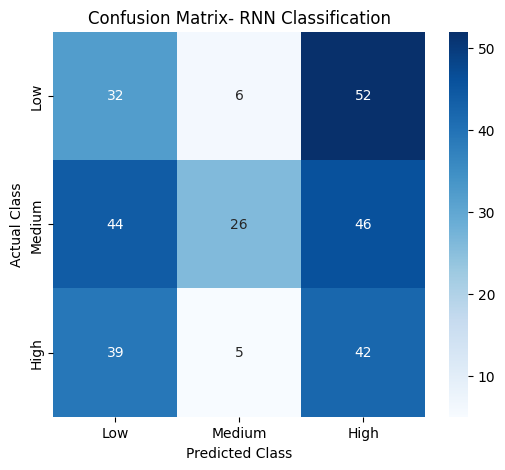

In [28]:
#Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix- RNN Classification')
plt.show()

In [18]:
## Regression with Random Forest

df = final_dataset

# Define features X and target y
#    Drop columns you don’t want the model to see
drop_cols = ['id', 'date', 'period']   
X = df.drop(columns=drop_cols + ['mood', 'mood_class'])
y = df['mood']
groups = df['id']

# Hold‑out 20% of users for final evaluation
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]

# GridSearchCV setup (5‑fold GroupKFold tuning on MAE)
group_kfold = GroupKFold(n_splits=5)
param_grid = {
    'n_estimators':      [100, 200, 500],
    'max_depth':         [None, 10, 20],
    'min_samples_leaf':  [1, 2, 4],
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=group_kfold.split(X_train, y_train, groups_train),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=2
)

# Run the grid search
grid.fit(X_train, y_train)
print("Best RF params:", grid.best_params_)

# Final evaluation on the held‑out 20%
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Test MSE: {mean_squared_error(y_test, y_pred):.4f}")

importances = best_rf.feature_importances_
feature_names = X.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(10))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best RF params: {'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 200}
Test MAE: 0.4422
Test MSE: 0.3467
mood_avg                               0.413782
appCat.entertainment_avg               0.074347
arousal_avg                            0.070042
appCat.merged_builtin_utilities_avg    0.058276
activity_avg                           0.058105
appCat.social_avg                      0.054655
valence_avg                            0.048407
appCat.merged_other_unknown_avg        0.046355
screen_avg                             0.043755
sms_call_sum_weighted_avg              0.043082
dtype: float64


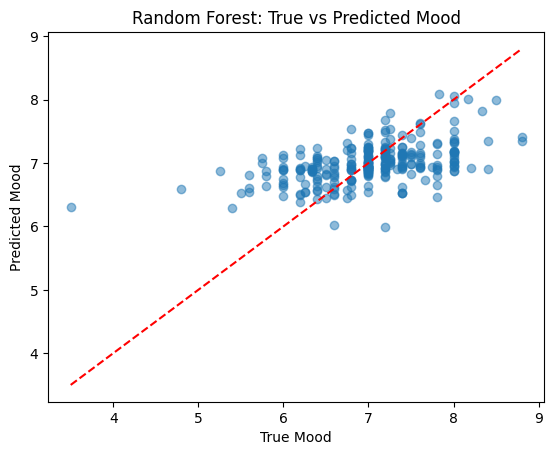

In [19]:
# Plot predicted vs. true mood values 
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("True Mood")
plt.ylabel("Predicted Mood")
plt.title("Random Forest: True vs Predicted Mood")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

In [ ]:
# Manual grid‐search for LSTM regression with GroupKFold

import warnings
warnings.filterwarnings('ignore')
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TensorFlow logs

from itertools import product

# 1) Define features and target
features = [
    'activity', 'circumplex.arousal', 'circumplex.valence',
    'appCat.builtin_utilities', 'appCat.other_unknown', 'appCat.communication',
    'appCat.entertainment', 'appCat.finance', 'appCat.game',
    'appCat.office', 'appCat.social', 'appCat.travel',
    'call_sms', 'screen'
]
target = 'mood'

# 2) Load and preprocess
df = imputed_data.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['id', 'date'])
df['day_diff'] = df.groupby('id')['date'].diff().dt.days
df['gap'] = df['day_diff'] > 1
df['seq_group'] = df.groupby('id')['gap'].cumsum().fillna(0).astype(int)

# 3) Sequence‐making function
def create_sequences(dataframe, feature_list, target_col, seq_len=3):
    X, y, groups = [], [], []
    grouped = dataframe.groupby(['id', 'seq_group'])
    for (user, seq_group), group in grouped:
        group = group.reset_index(drop=True)
        for i in range(len(group) - seq_len):
            seq_x = group[feature_list].iloc[i:i+seq_len].values
            seq_y = group[target_col].iloc[i + seq_len]
            X.append(seq_x)
            y.append(seq_y)
            groups.append(user)
    return np.array(X), np.array(y), np.array(groups)

# 4) Split users into train/test
unique_users = df['id'].unique()
train_users, test_users = train_test_split(unique_users, test_size=0.2, random_state=42)
train_df = df[df['id'].isin(train_users)]
test_df  = df[df['id'].isin(test_users)]

X_train, y_train, groups_train = create_sequences(train_df, features, target, seq_len=3)
X_test,  y_test,  groups_test  = create_sequences(test_df,  features, target, seq_len=3)

# 5) Model factory for tuning
def build_model(units, lr):
    model = Sequential([
        LSTM(units, input_shape=(3, len(features)), activation='tanh'),
        Dense(1, activation='linear')
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss=MeanSquaredError(),
        metrics=['mae']
    )
    return model

# Regression manual grid‐search with print‐based progress and warning suppression


param_grid = {
    'units':      [32, 64, 128],
    'lr':         [1e-3, 1e-4],
    'batch_size': [16, 32],
    'epochs':     [20],
}

# prepare all combinations
combos = list(product(
    param_grid['units'],
    param_grid['lr'],
    param_grid['batch_size'],
    param_grid['epochs']
))
results = []

total = len(combos)
for idx, (units, lr, batch_size, epochs) in enumerate(combos, start=1):
    print(f"[{idx}/{total}] units={units}, lr={lr}, batch_size={batch_size}, epochs={epochs}")
    fold_mses = []
    for train_idx, val_idx in cv.split(X_train, y_train, groups_train):
        K.clear_session()
        model = build_model(units, lr)
        model.fit(
            X_train[train_idx], y_train[train_idx],
            batch_size=batch_size, epochs=epochs,
            verbose=0
        )
        mse, _ = model.evaluate(
            X_train[val_idx], y_train[val_idx],
            verbose=0
        )
        fold_mses.append(mse)
    results.append({
        'units':      units,
        'lr':         lr,
        'batch_size': batch_size,
        'epochs':     epochs,
        'mean_mse':   sum(fold_mses) / len(fold_mses)
    })

# after this you can wrap results into a DataFrame as before


# 8) Select best hyper‐parameters
results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['mean_mse'].idxmin()]
print("Best hyper‐parameters (lowest CV MSE):")
print(best_row)

# 9) Re‐fit best model on full training set & evaluate
best_params = best_row.to_dict()
K.clear_session()
final_model = build_model(
    units    = int(best_params['units']),
    lr       = best_params['lr']
)
final_model.fit(
    X_train, y_train,
    batch_size = int(best_params['batch_size']),
    epochs     = int(best_params['epochs']),
    verbose    = 0
)

test_mse, test_mae = final_model.evaluate(X_test, y_test, verbose=0)
print(f"Test MSE: {test_mse:.4f},  Test MAE: {test_mae:.4f}")


[1/12] units=32, lr=0.001, batch_size=16, epochs=20
[2/12] units=32, lr=0.001, batch_size=32, epochs=20
[3/12] units=32, lr=0.0001, batch_size=16, epochs=20
[4/12] units=32, lr=0.0001, batch_size=32, epochs=20
[5/12] units=64, lr=0.001, batch_size=16, epochs=20
[6/12] units=64, lr=0.001, batch_size=32, epochs=20
[7/12] units=64, lr=0.0001, batch_size=16, epochs=20
[8/12] units=64, lr=0.0001, batch_size=32, epochs=20
[9/12] units=128, lr=0.001, batch_size=16, epochs=20
[10/12] units=128, lr=0.001, batch_size=32, epochs=20
[11/12] units=128, lr=0.0001, batch_size=16, epochs=20
[12/12] units=128, lr=0.0001, batch_size=32, epochs=20
Best hyper‐parameters (lowest CV MSE):
units         64.000000
lr             0.001000
batch_size    16.000000
epochs        20.000000
mean_mse       1.083365
Name: 4, dtype: float64
Test MSE: 0.6595,  Test MAE: 0.6361


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


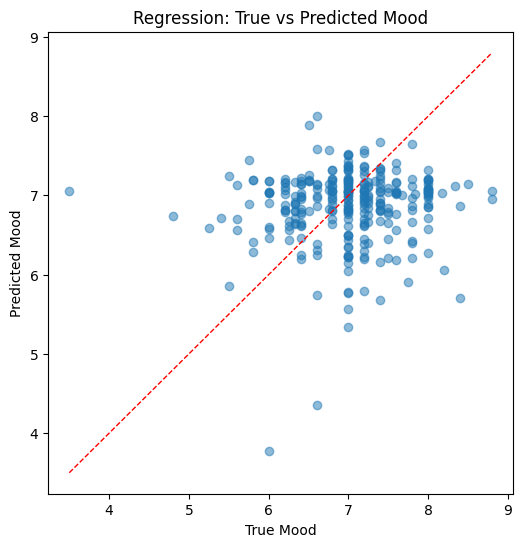

In [31]:
# get your predictions (shape will be (n_samples, 1))
y_pred = final_model.predict(X_test)

# flatten to a 1‑D array
y_pred = y_pred.ravel()

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=1
)
plt.xlabel("True Mood")
plt.ylabel("Predicted Mood")
plt.title("Regression: True vs Predicted Mood")
plt.show()
